In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [5]:
df = pd.read_csv("diabetes.csv")  # download from Kaggle / sklearn datasets

df.head()
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [6]:
# Check missing values
print(df.isnull().sum())

# Replace 0 values (invalid in some columns) with median
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols:
    df[col] = df[col].replace(0, df[col].median())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


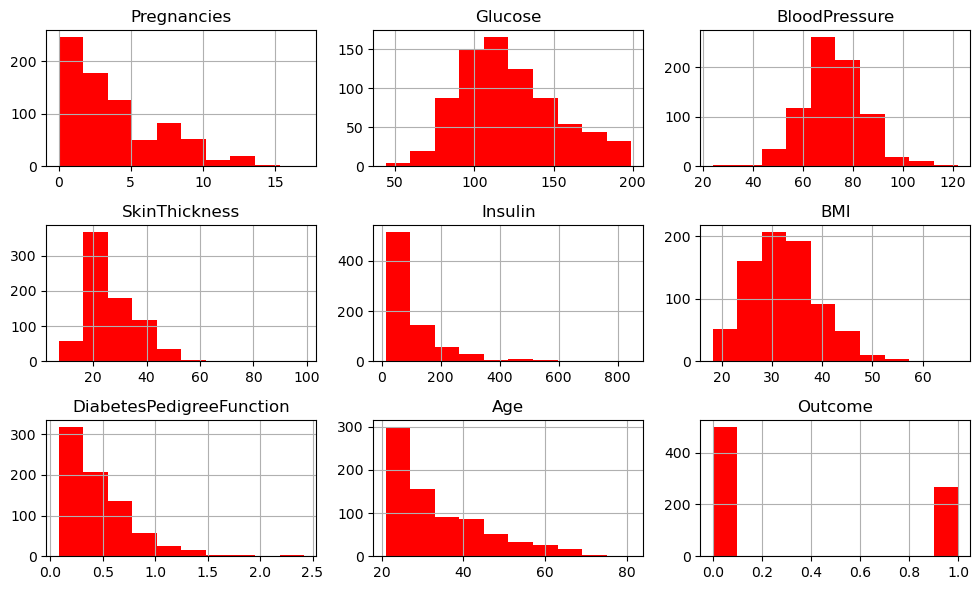

In [7]:
import matplotlib.pyplot as plt

df.hist(figsize=(10,6), color="red")
plt.tight_layout()
plt.show()

In [8]:
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.128213,0.208615,0.032568,-0.055697,0.021546,-0.033523,0.544341,0.221898
Glucose,0.128213,1.000000,0.218937,0.172143,0.357573,0.231400,0.137327,0.266909,0.492782
BloodPressure,0.208615,0.218937,1.000000,0.147809,-0.028721,0.281132,-0.002378,0.324915,0.165723
SkinThickness,0.032568,0.172143,0.147809,1.000000,0.238188,0.546951,0.142977,0.054514,0.189065
Insulin,-0.055697,0.357573,-0.028721,0.238188,1.000000,0.189022,0.178029,-0.015413,0.148457
BMI,0.021546,0.231400,0.281132,0.546951,0.189022,1.000000,0.153506,0.025744,0.312249
DiabetesPedigreeFunction,-0.033523,0.137327,-0.002378,0.142977,0.178029,0.153506,1.000000,0.033561,0.173844
Age,0.544341,0.266909,0.324915,0.054514,-0.015413,0.025744,0.033561,1.000000,0.238356
Outcome,0.221898,0.492782,0.165723,0.189065,0.148457,0.312249,0.173844,0.238356,1.000000


In [32]:
df.shape
# df.dtypes

(768, 9)

In [11]:
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

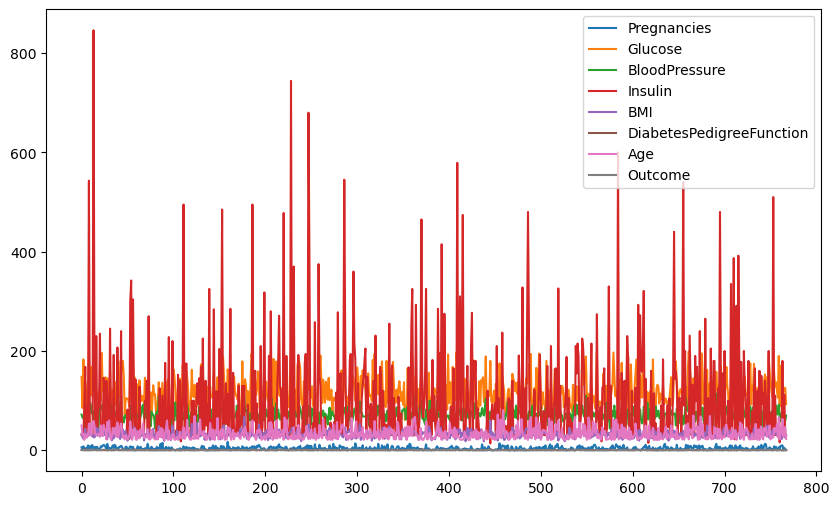

In [12]:
data1 = df.loc[:, [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]]
data1.plot(figsize=(10,6))
plt.show()

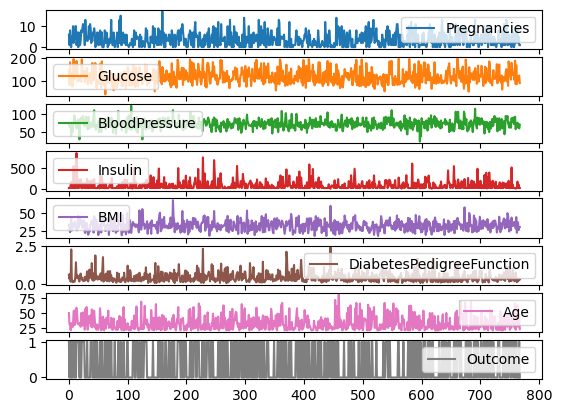

In [13]:
data1.plot(subplots=True)
plt.show()

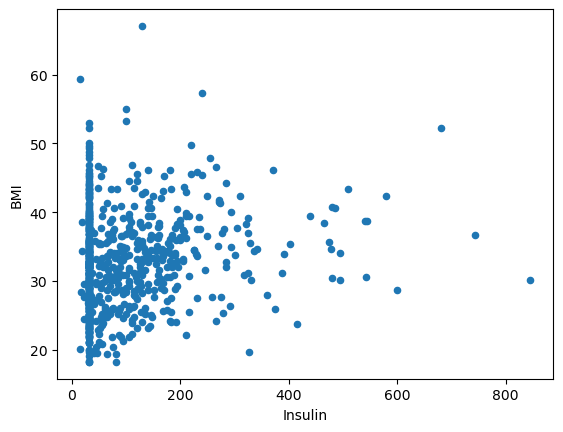

In [14]:
data1.plot(kind="scatter", x="Insulin", y="BMI")
plt.show()

In [15]:
data1.dropna()

,Pregnancies,Glucose,BloodPressure,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,30.5,33.6,0.627,50,1
1,1,85,66,30.5,26.6,0.351,31,0
2,8,183,64,30.5,23.3,0.672,32,1
3,1,89,66,94.0,28.1,0.167,21,0
4,0,137,40,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...
763,10,101,76,180.0,32.9,0.171,63,0
764,2,122,70,30.5,36.8,0.340,27,0
765,5,121,72,112.0,26.2,0.245,30,0
766,1,126,60,30.5,30.1,0.349,47,1


In [16]:
#Checking if the Glucose, BMI , BloodPressure, insulin and SkinThickness columns have values of 0.
zero_values= (data1[['Glucose', 'Insulin', 'BloodPressure', 'BMI']] == 0).sum()
print(zero_values)

Glucose          0
Insulin          0
BloodPressure    0
BMI              0
dtype: int64


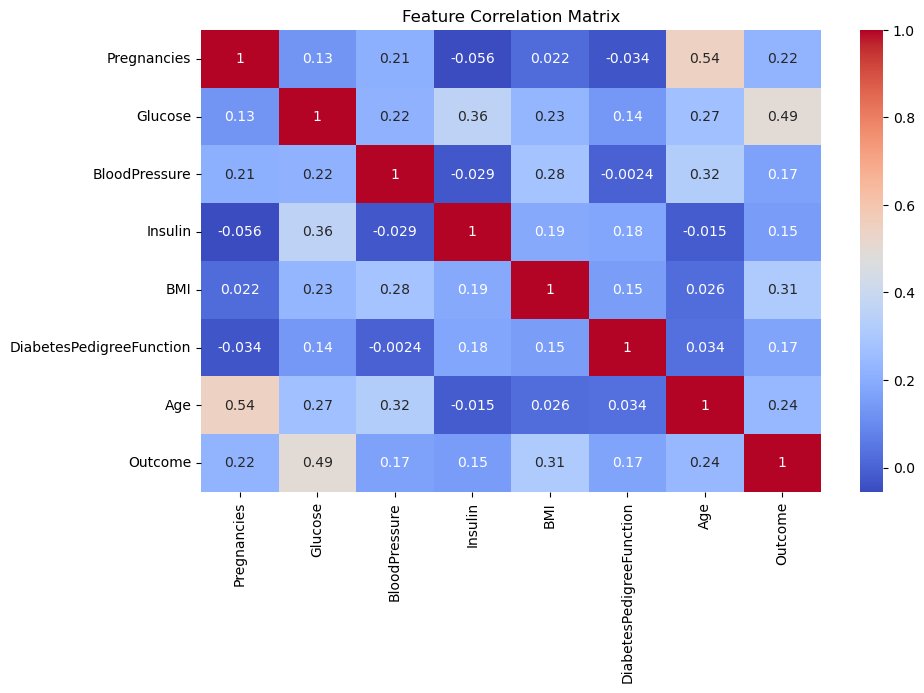

In [17]:
import seaborn as sns
plt.figure(figsize=(10,6))
sns.heatmap(data1.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Train
X_train = scaler.fit_transform(X_train)

# Test
X_test = scaler.transform(X_test)

In [29]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [33]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42
)
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, n_estimators=200, random_state=42)

In [34]:
y_pred = model.predict(X_test)

In [35]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7727272727272727

Confusion Matrix:
 [[85 14]
 [21 34]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.86      0.83        99
           1       0.71      0.62      0.66        55

    accuracy                           0.77       154
   macro avg       0.76      0.74      0.74       154
weighted avg       0.77      0.77      0.77       154



In [36]:
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7532467532467533


In [37]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(RandomForestClassifier(), params, cv=5)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

model = grid.best_estimator_
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Best Params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 300}
Accuracy: 0.7337662337662337


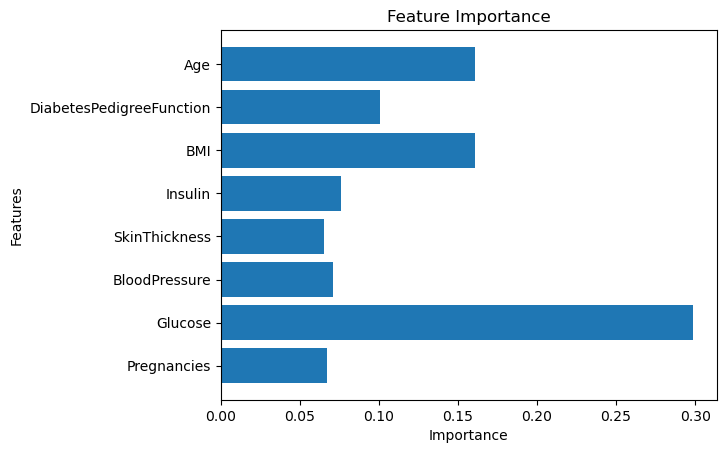

In [25]:
import matplotlib.pyplot as plt

importance = model.feature_importances_
features = X.columns

plt.barh(features, importance)
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance")
plt.show()

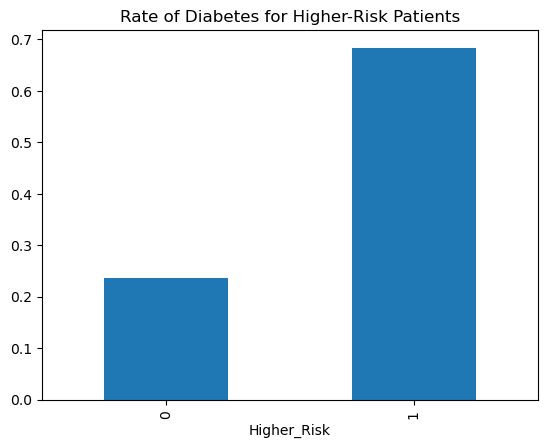

In [26]:
data1['Higher_Risk'] = ((data1['Glucose'] >= 139) & (data1['BMI'] >= 25)).astype(int)

data1.groupby('Higher_Risk')['Outcome'].mean().plot(kind='bar')
plt.title('Rate of Diabetes for Higher-Risk Patients')
plt.show()

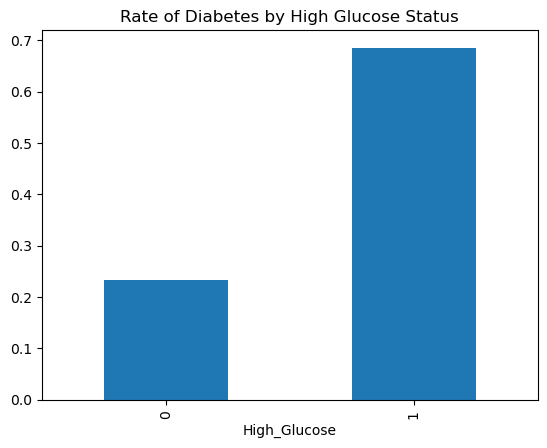

In [27]:
data1['High_Glucose'] = (data1['Glucose'] >= 140).astype(int)

data1.groupby('High_Glucose')['Outcome'].mean().plot(kind='bar')
plt.title('Rate of Diabetes by High Glucose Status')
plt.show()
